In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the Sugarcane Irrigation dataset
df = pd.read_csv("Sugarcane_Irrigation_Dataset_5000.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (5000, 17)


,rainfall_mm,avg_temperature_celsius,sunlight_hours_per_day,nitrogen_n_kg_per_acre,phosphorus_p_kg_per_acre,potassium_k_kg_per_acre,soil_type,crop_duration_days,irrigation_frequency_per_month,pest_control_applied,seed_variety,yield_quintal_per_acre,soil_ph,relative_humidity_percent,wind_speed_kmph,soil_moisture_percent,water_requirement_liters_per_day
0,1734.13,33.61,8.95,214.67,76.90,94.82,Alluvial,400,3,1.00,Co86032,520.17,6.82,88.9,10.1,36.1,15.9
1,1286.61,31.25,7.89,163.85,61.71,80.61,Alluvial,374,3,0.95,CoM0265,463.89,6.99,82.2,8.1,28.1,18.2
2,1323.73,29.54,7.52,133.31,48.41,65.28,Red Soil,352,2,0.99,Co0238,343.14,6.50,77.9,8.6,35.0,18.5
3,1459.15,32.62,8.55,190.85,69.67,82.79,Clay Loam,384,4,1.00,Co0238,508.21,6.83,87.5,10.7,33.0,19.6
4,1114.87,30.31,7.92,148.93,57.00,71.42,Clay Loam,359,4,1.00,CoM0265,433.10,7.10,79.0,20.1,25.8,18.6


In [ ]:
# Numerical features selected for scaling
numerical_features = [
    "rainfall_mm",
    "avg_temperature_celsius",
    "soil_moisture_percent",
    "yield_quintal_per_acre"
]

# Nominal categorical features selected for One-Hot Encoding
one_hot_features = [
    "soil_type",
    "seed_variety"
]

# Categorical feature selected for Label Encoding
label_feature = "pest_control_applied"

print("Numerical Features:", numerical_features)
print("One-Hot Encoding Features:", one_hot_features)
print("Label Encoding Feature:", label_feature)

Numerical Features: ['rainfall_mm', 'avg_temperature_celsius', 'soil_moisture_percent', 'yield_quintal_per_acre']
One-Hot Encoding Features: ['soil_type', 'seed_variety']
Label Encoding Feature: pest_control_applied


The selected attributes cover both numerical and categorical data
rainfall_mm, avg_temperature_celsius, soil_moisture_percent, and yield_quintal_per_acre were selected because they are important numerical factors for analyzing sugarcane irrigation conditions and crop performance.
soil_type and seed_variety are nominal categorical variables with no inherent order, so One-Hot Encoding is appropriate.
pest_control_applied is a binary categorical variable (Yes/No), so it can be represented using Label Encoding as 0 and 1.
This selection provides a suitable combination of attributes to demonstrate Min-Max Scaling, Standardization, One-Hot Encoding, and Label Encoding on the sugarcane dataset.

In [ ]:
# Manual Min-Max Scaling

minmax_manual = df[numerical_features].copy()

for column in numerical_features:
    minmax_manual[column] = (
        df[column] - df[column].min()
    ) / (
        df[column].max() - df[column].min()
    )

print("Manually Min-Max Scaled Data:")
minmax_manual.head()

Manually Min-Max Scaled Data:


,rainfall_mm,avg_temperature_celsius,soil_moisture_percent,yield_quintal_per_acre
0,0.798402,0.817241,0.611801,0.846352
1,0.415906,0.545977,0.363354,0.702781
2,0.447632,0.349425,0.577640,0.394745
3,0.563376,0.703448,0.515528,0.815842
4,0.269120,0.437931,0.291925,0.624235


Min-Max Scaling was manually applied to rainfall, average temperature, soil moisture, and sugarcane yield because these numerical attributes are relevant to the irrigation and crop-performance analysis. The transformation brings the selected variables to a common 0–1 scale, making them comparable and suitable for further machine-learning analysis.

In [ ]:
# Verify Min-Max Scaling

print("Minimum values:")
print(minmax_manual.min())

print("\nMaximum values:")
print(minmax_manual.max())

Minimum values:
rainfall_mm                0.0
avg_temperature_celsius    0.0
soil_moisture_percent      0.0
yield_quintal_per_acre     0.0
dtype: float64

Maximum values:
rainfall_mm                1.0
avg_temperature_celsius    1.0
soil_moisture_percent      1.0
yield_quintal_per_acre     1.0
dtype: float64


The verification confirms that Min-Max Scaling has successfully transformed all selected numerical attributes to the 0–1 range, making them comparable despite their different original scales

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max Scaling
minmax_sklearn = df[numerical_features].copy()

minmax_sklearn[numerical_features] = scaler.fit_transform(
    df[numerical_features]
)

print("Min-Max Scaled Data using Scikit-Learn:")
display(minmax_sklearn.head())

Min-Max Scaled Data using Scikit-Learn:


,rainfall_mm,avg_temperature_celsius,soil_moisture_percent,yield_quintal_per_acre
0,0.798402,0.817241,0.611801,0.846352
1,0.415906,0.545977,0.363354,0.702781
2,0.447632,0.349425,0.577640,0.394745
3,0.563376,0.703448,0.515528,0.815842
4,0.269120,0.437931,0.291925,0.624235


The Scikit-Learn implementation provides the same Min-Max normalization as the manual formula, but with a simpler and more efficient implementation. The transformed numerical features are now on a common scale, making them suitable for further machine-learning analysis.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create Label Encoder
label_encoder = LabelEncoder()

# Apply Label Encoding
df["pest_control_encoded"] = label_encoder.fit_transform(
    df["pest_control_applied"]
)

print("Label Encoding Mapping:")
for category, code in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(category, "->", code)

display(df[["pest_control_applied", "pest_control_encoded"]].head())

Label Encoding Mapping:
0.0 -> 0
0.01 -> 1
0.02 -> 2
0.03 -> 3
0.04 -> 4
0.05 -> 5
0.06 -> 6
0.07 -> 7
0.08 -> 8
0.09 -> 9
0.1 -> 10
0.11 -> 11
0.12 -> 12
0.13 -> 13
0.14 -> 14
0.15 -> 15
0.16 -> 16
0.17 -> 17
0.18 -> 18
0.19 -> 19
0.2 -> 20
0.21 -> 21
0.22 -> 22
0.23 -> 23
0.24 -> 24
0.25 -> 25
0.27 -> 26
0.32 -> 27
0.35 -> 28
0.65 -> 29
0.69 -> 30
0.7 -> 31
0.71 -> 32
0.72 -> 33
0.73 -> 34
0.74 -> 35
0.75 -> 36
0.76 -> 37
0.77 -> 38
0.78 -> 39
0.79 -> 40
0.8 -> 41
0.81 -> 42
0.82 -> 43
0.83 -> 44
0.84 -> 45
0.85 -> 46
0.86 -> 47
0.87 -> 48
0.88 -> 49
0.89 -> 50
0.9 -> 51
0.91 -> 52
0.92 -> 53
0.93 -> 54
0.94 -> 55
0.95 -> 56
0.96 -> 57
0.97 -> 58
0.98 -> 59
0.99 -> 60
1.0 -> 61


,pest_control_applied,pest_control_encoded
0,1.00,61
1,0.95,56
2,0.99,60
3,1.00,61
4,1.00,61


pest_control_applied is a binary categorical attribute, so it is represented numerically as 0 and 1. This makes the categorical information usable by machine-learning algorithms while retaining the original Yes/No information.

In [ ]:
# One-Hot Encoding for nominal categorical features

one_hot_encoded = pd.get_dummies(
    df[one_hot_features],
    drop_first=True
)

print("One-Hot Encoded Data:")
display(one_hot_encoded.head())

One-Hot Encoded Data:


,soil_type_Clay Loam,soil_type_Red Soil,soil_type_Sandy Loam,seed_variety_Co86032,seed_variety_CoM0265
0,False,False,False,True,False
1,False,False,False,False,True
2,False,True,False,False,False
3,True,False,False,False,False
4,True,False,False,False,True


Each category in soil_type and seed_variety is converted into a separate binary (0/1) column.

drop_first=True removes one category from each feature to help prevent the Dummy Variable Trap.

soil_type and seed_variety are nominal variables. For example, Alluvial soil is not "greater than" Clay Loam soil, so assigning labels such as 0, 1, 2 would incorrectly imply an order. One-Hot Encoding avoids this problem.

In [ ]:
# Compare original and transformed data

print("Original Data:")
display(df[numerical_features].head())

print("Min-Max Scaled Data:")
display(minmax_sklearn.head())

Original Data:


,rainfall_mm,avg_temperature_celsius,soil_moisture_percent,yield_quintal_per_acre
0,1734.13,33.61,36.1,520.17
1,1286.61,31.25,28.1,463.89
2,1323.73,29.54,35.0,343.14
3,1459.15,32.62,33.0,508.21
4,1114.87,30.31,25.8,433.10


Min-Max Scaled Data:


,rainfall_mm,avg_temperature_celsius,soil_moisture_percent,yield_quintal_per_acre
0,0.798402,0.817241,0.611801,0.846352
1,0.415906,0.545977,0.363354,0.702781
2,0.447632,0.349425,0.577640,0.394745
3,0.563376,0.703448,0.515528,0.815842
4,0.269120,0.437931,0.291925,0.624235


The original numerical attributes have different ranges and units, while the transformed attributes are converted to a common 0–1 scale. This confirms that Min-Max Scaling changes the scale of the data without changing the relative pattern of the observations.

In [ ]:
print("Label Encoded Data:")
display(df[["pest_control_applied", "pest_control_encoded"]].head())

print("\nOne-Hot Encoded Data:")
display(one_hot_encoded.head())

Label Encoded Data:


,pest_control_applied,pest_control_encoded
0,1.00,61
1,0.95,56
2,0.99,60
3,1.00,61
4,1.00,61



One-Hot Encoded Data:


,soil_type_Clay Loam,soil_type_Red Soil,soil_type_Sandy Loam,seed_variety_Co86032,seed_variety_CoM0265
0,False,False,False,True,False
1,False,False,False,False,True
2,False,True,False,False,False
3,True,False,False,False,False
4,True,False,False,False,True


pest_control_applied is represented using 0/1 Label Encoding.
soil_type and seed_variety are represented using One-Hot Encoding.
drop_first=True removes the first category of each nominal feature, reducing redundant dummy variables.

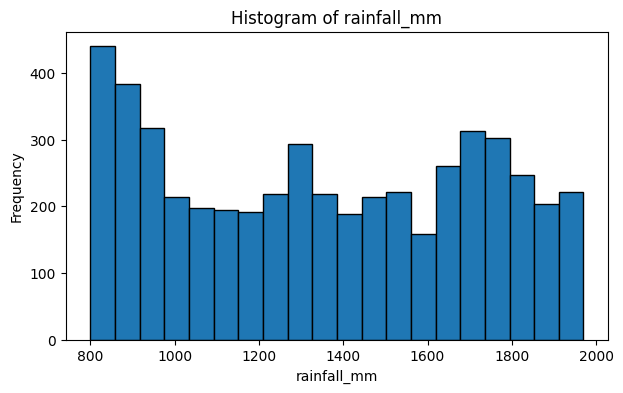

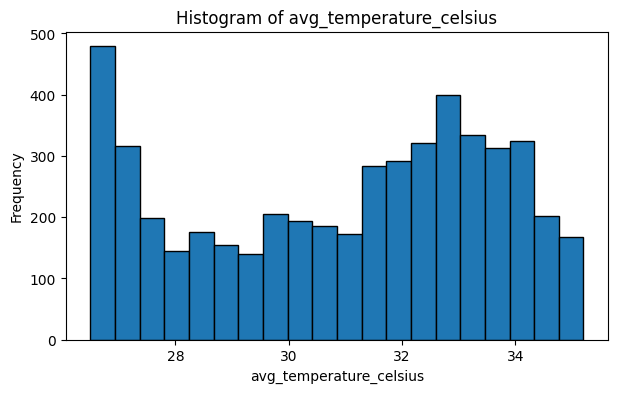

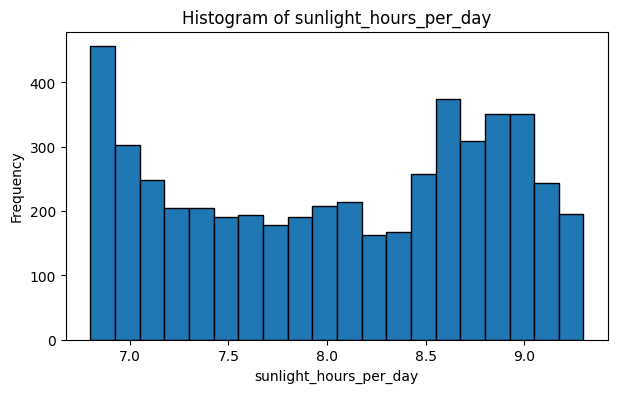

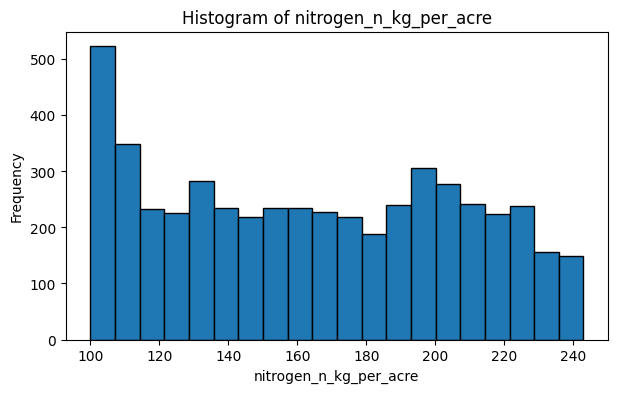

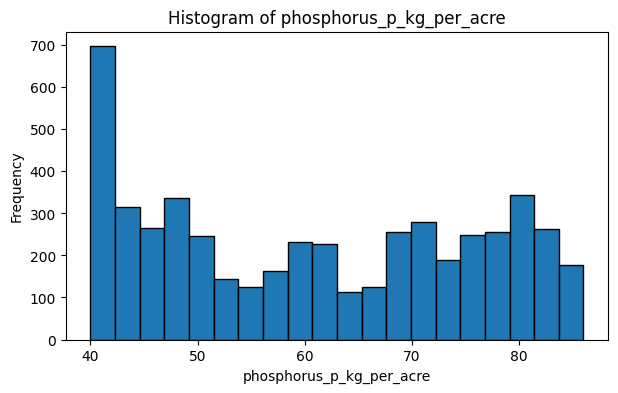

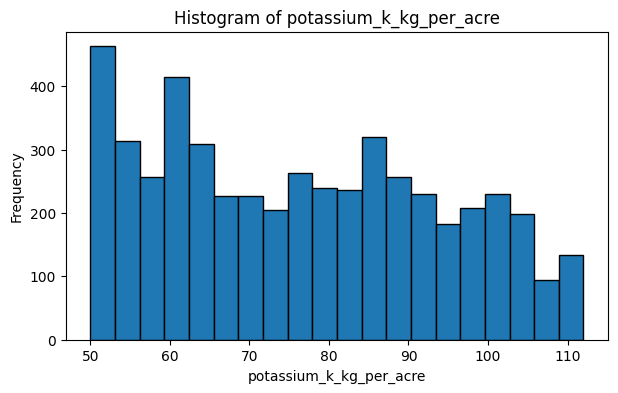

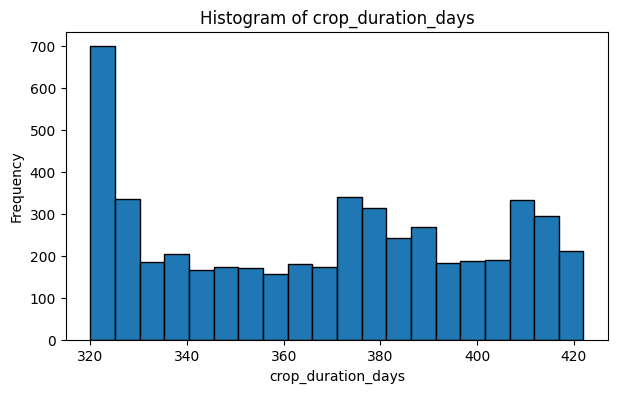

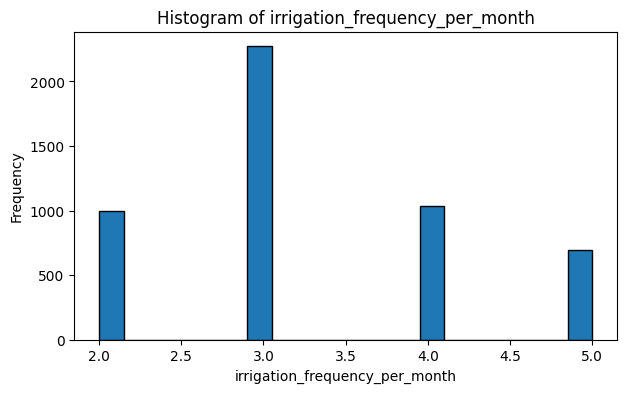

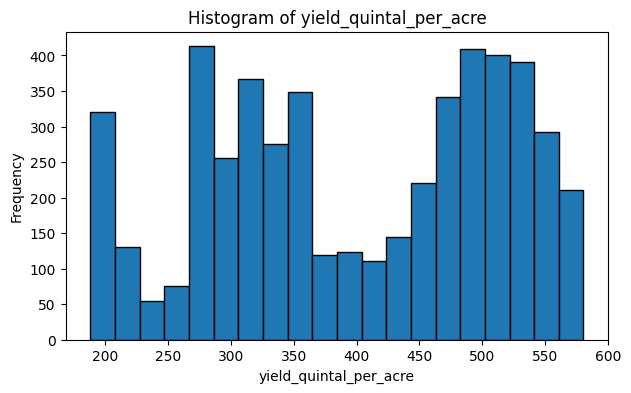

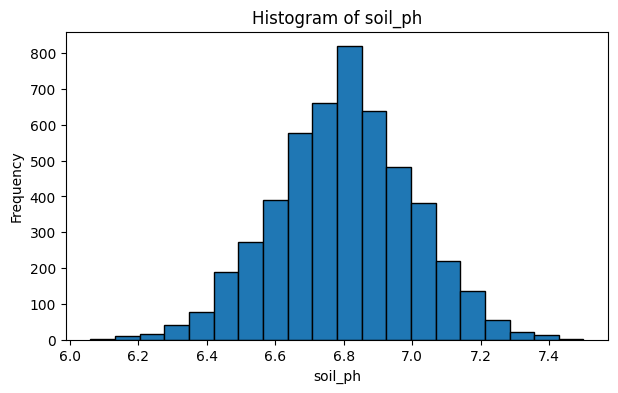

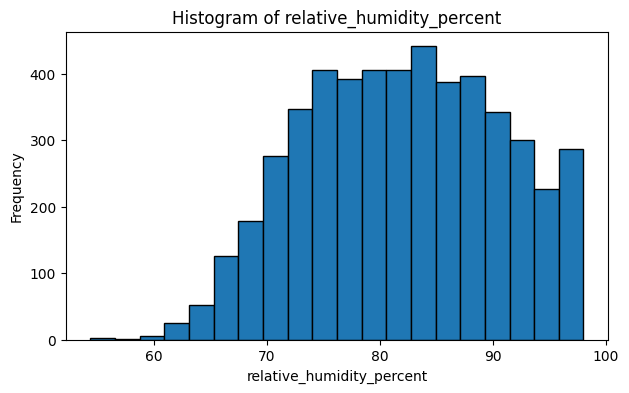

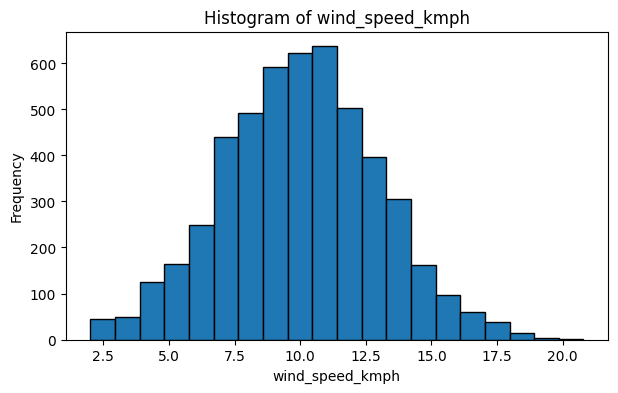

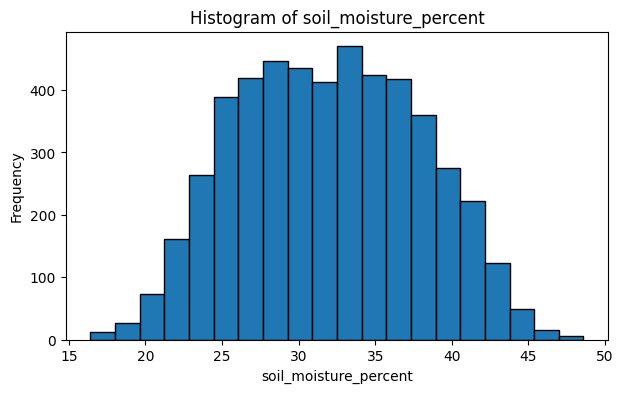

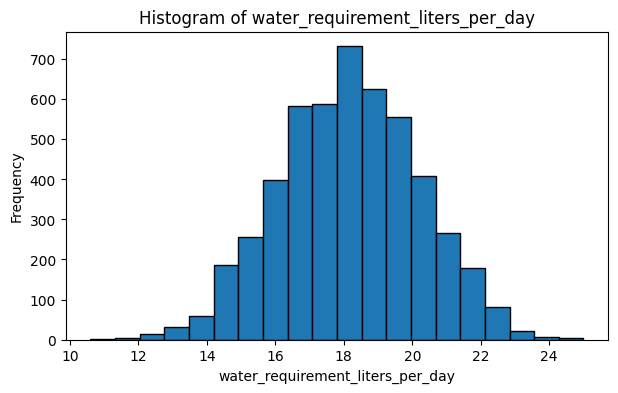

In [ ]:
numerical_columns = [
    "rainfall_mm",
    "avg_temperature_celsius",
    "sunlight_hours_per_day",
    "nitrogen_n_kg_per_acre",
    "phosphorus_p_kg_per_acre",
    "potassium_k_kg_per_acre",
    "crop_duration_days",
    "irrigation_frequency_per_month",
    "yield_quintal_per_acre",
    "soil_ph",
    "relative_humidity_percent",
    "wind_speed_kmph",
    "soil_moisture_percent",
    "water_requirement_liters_per_day"
]

for column in numerical_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column], bins=20, edgecolor="black")
    plt.title("Histogram of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

| Numerical Attribute                | Histogram Shape / Distribution                     |
| ---------------------------------- | -------------------------------------------------- |
| `rainfall_mm`                      | Irregular / multimodal distribution                |
| `avg_temperature_celsius`          | Approximately symmetric distribution               |
| `sunlight_hours_per_day`           | Approximately symmetric distribution               |
| `nitrogen_n_kg_per_acre`           | Approximately symmetric distribution               |
| `phosphorus_p_kg_per_acre`         | Approximately symmetric distribution               |
| `potassium_k_kg_per_acre`          | Approximately symmetric distribution               |
| `crop_duration_days`               | Approximately symmetric distribution               |
| `irrigation_frequency_per_month`   | Discrete / irregular distribution                  |
| `yield_quintal_per_acre`           | Bimodal / multimodal distribution                  |
| `soil_ph`                          | Approximately symmetric distribution               |
| `relative_humidity_percent`        | Approximately symmetric distribution               |
| `wind_speed_kmph`                  | Right-skewed distribution                          |
| `soil_moisture_percent`            | Approximately symmetric / bell-shaped distribution |
| `water_requirement_liters_per_day` | Right-skewed / irregular distribution              |


CONCLUSION

The experiment demonstrated data preprocessing and exploratory analysis on the sugarcane irrigation dataset. Numerical attributes were normalized using manual Min-Max Scaling and Scikit-Learn's MinMaxScaler, while categorical attributes were converted using Label Encoding and One-Hot Encoding. Histograms of rainfall, soil moisture, and yield were also analyzed to study their distributions and skewness.